# MPtrj Metadata Exploratory Data Analysis

This notebook analyzes the metadata arrays (`metadata.npz` and `metadata_num-edges.npz`) generated for the MPtrj subsets to observe the distribution of atoms and edges.
It will help us understand the structural density and determine safe `max_atoms` cutoff thresholds to avoid OOM issues during GPU training.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Set the path to your subset directory (adjust if running from a different folder)
subset_dir = "../../dataset/mptrj/aselmdb_uncorrected_total_energy_160k"
# subset_dir = "../../dataset/salex/val_30k"

atoms_meta_path = os.path.join(subset_dir, "metadata_num-nodes.npz")
edges_meta_path = os.path.join(subset_dir, "metadata_num-edges.npz")

## 1. Distribution of the Number of Atoms

Total structures: 160,000
Min atoms: 1
Max atoms: 444
Mean atoms: 31.1
------------------------------
50th percentile: 22 atoms
75th percentile: 40 atoms
90th percentile: 68 atoms
95th percentile: 88 atoms
99th percentile: 144 atoms
99.9th percentile: 216 atoms


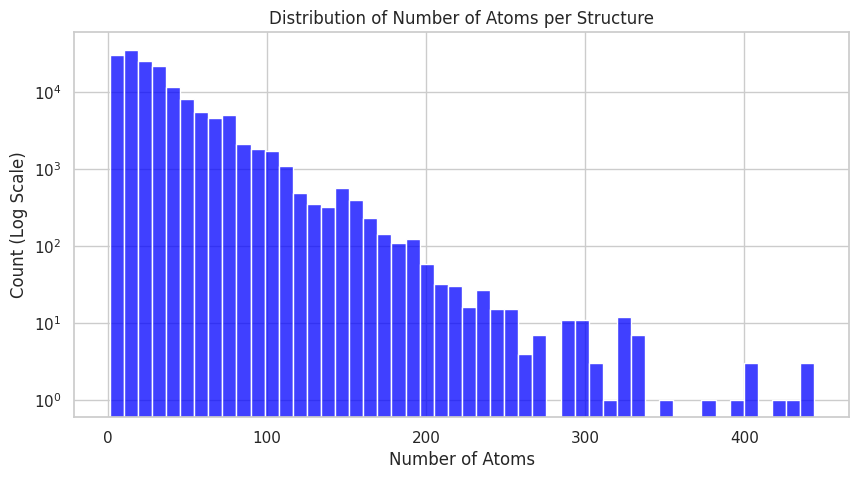

In [9]:
if os.path.exists(atoms_meta_path):
    atoms_data = np.load(atoms_meta_path)['natoms']
    
    print(f"Total structures: {len(atoms_data):,}")
    print(f"Min atoms: {atoms_data.min()}")
    print(f"Max atoms: {atoms_data.max()}")
    print(f"Mean atoms: {atoms_data.mean():.1f}")
    print("-" * 30)
    for p in [50, 75, 90, 95, 99, 99.9]:
        print(f"{p}th percentile: {np.percentile(atoms_data, p):.0f} atoms")
        
    plt.figure(figsize=(10, 5))
    sns.histplot(atoms_data, bins=50, kde=False, color='blue')
    plt.title('Distribution of Number of Atoms per Structure')
    plt.xlabel('Number of Atoms')
    plt.ylabel('Count (Log Scale)')
    plt.yscale('log')
    plt.show()
else:
    print(f"Could not find {atoms_meta_path}")

## 2. Distribution of the Number of Edges

The number of edges is typically what limits memory for dense geometric models like EquiformerV3. We use the `metadata_num-edges.npz` file generated by `create_metadata_num_edges.py`.
*(Note: The script saves the edge counts under the `natoms` dictionary key)*

Total structures: 160,000
Min edges: 2
Max edges: 32708
Mean edges: 1930.3
------------------------------
50th percentile: 1312 edges
75th percentile: 2560 edges
90th percentile: 4488 edges
95th percentile: 5962 edges
99th percentile: 9776 edges
99.9th percentile: 16840 edges


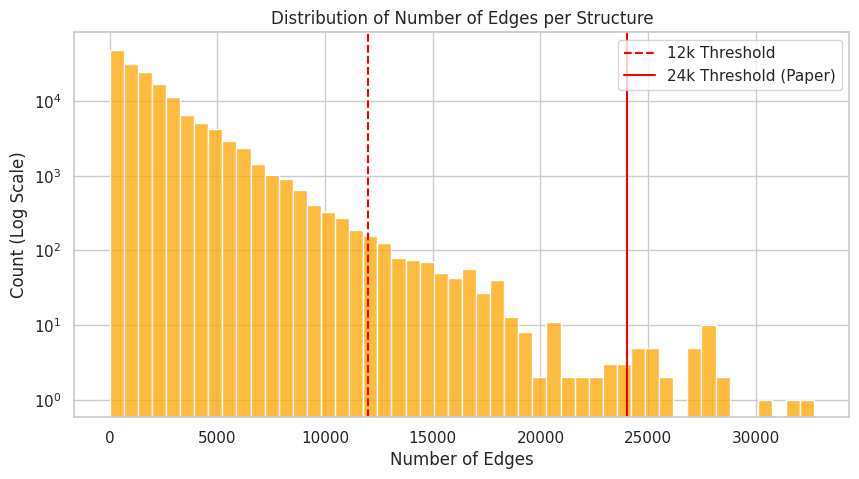


--- Filter Impact Analysis ---
Threshold 8000: Drops 3,284 structures (2.05%)
Threshold 10000: Drops 1,492 structures (0.93%)
Threshold 12000: Drops 736 structures (0.46%)
Threshold 15000: Drops 299 structures (0.19%)
Threshold 24000: Drops 33 structures (0.02%)


In [10]:
if os.path.exists(edges_meta_path):
    edges_data = np.load(edges_meta_path)['natoms']
    
    print(f"Total structures: {len(edges_data):,}")
    print(f"Min edges: {edges_data.min()}")
    print(f"Max edges: {edges_data.max()}")
    print(f"Mean edges: {edges_data.mean():.1f}")
    print("-" * 30)
    for p in [50, 75, 90, 95, 99, 99.9]:
        print(f"{p}th percentile: {np.percentile(edges_data, p):.0f} edges")
        
    plt.figure(figsize=(10, 5))
    sns.histplot(edges_data, bins=50, kde=False, color='orange')
    
    # Draw vertical lines for potential thresholds
    # plt.axvline(10000, color='red', linestyle=':', label='10k Threshold')
    plt.axvline(12000, color='red', linestyle='--', label='12k Threshold')
    plt.axvline(24000, color='red', linestyle='-', label='24k Threshold (Paper)')
    
    plt.title('Distribution of Number of Edges per Structure')
    plt.xlabel('Number of Edges')
    plt.ylabel('Count (Log Scale)')
    plt.yscale('log')
    plt.legend()
    plt.show()
    
    print("\n--- Filter Impact Analysis ---")
    for threshold in [8000, 10000, 12000, 15000, 24000]:
        dropped = np.sum(edges_data > threshold)
        pct = dropped / len(edges_data) * 100
        print(f"Threshold {threshold}: Drops {dropped:,} structures ({pct:.2f}%)")
else:
    print(f"Could not find {edges_meta_path}. You might need to run `create_metadata_num_edges.py` first.")